# Redesigned Figure 1

This notebook creates an integrated 180 × 185 mm, double-column Figure 1. Panel a uses bars with overlaid posterior-mean points and uncertainty whiskers; panels b and c retain the original vertically stacked arrangement with one shared vertical colour bar. The figure is exported directly as vector PDF so text remains sharp and editable.


In [34]:
from pathlib import Path
import pickle
import sys

import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

ROOT = Path('/Users/tongli1997/Library/CloudStorage/OneDrive-UniversityofVictoria/Codes_run_on_local/Global_regional_attribution/Aug2026_review_round2')
DATA = ROOT / 'saved_data'
OUTPUT = ROOT / 'saved_figures'
OUTPUT.mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT / 'functions'))
from Plot_function import plot_ar6_region_data_on_ax_new, modify_cmap

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.65,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})


## Load and validate source data

In [35]:
def load_pickle(path):
    with path.open('rb') as handle:
        return pickle.load(handle)

warming = xr.open_dataarray(
    DATA / '2.0.real_obs_constrain_prior_post_warming_2016-2025_ref.1850-1900.nc'
).sel(scheme='post', forcing='ALL')
post_ref2025 = load_pickle(DATA / '2.2_constrained_46reg_lsat_smoothed_warming_ref2025_1850-2100.pkl')
post_ref1850 = load_pickle(DATA / '2.3_constrained_46reg_lsat_smoothed_warming_ref1850_1850-2100.pkl')

region_labels = warming['abbrevs'].values.astype(str)
assert len(region_labels) == 47, 'Expected 46 AR6 land regions plus global land.'
assert set(warming['quantile'].values.astype(str)) == {'mean', '5th', '95th'}
assert np.all(warming.sel(quantile='5th') <= warming.sel(quantile='mean'))
assert np.all(warming.sel(quantile='mean') <= warming.sel(quantile='95th'))

# Median threshold years from the posterior global-mean trajectory.
year_15, year_20 = 2029, 2042
current = post_ref1850.sel(year=2025, quantile='mean').squeeze()
remaining_15 = post_ref2025.sel(year=slice(year_15 - 5, year_15 + 5)).mean('year').squeeze()
remaining_20 = post_ref2025.sel(year=slice(year_20 - 5, year_20 + 5)).mean('year').squeeze()
achieved_15 = 100 * current / (current + remaining_15)
achieved_20 = 100 * current / (current + remaining_20)
map_15 = achieved_15.sel(quantile='mean').isel(region=slice(0, 46))
map_20 = achieved_20.sel(quantile='mean').isel(region=slice(0, 46))
global_15 = float(achieved_15.sel(quantile='mean').isel(region=46))
global_20 = float(achieved_20.sel(quantile='mean').isel(region=46))


## Plotting helpers

In [36]:
CONTINENT_REGIONS = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Antarctica': ['EAN', 'WAN'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Global land': ['LSAT'],
}
CONTINENT_COLORS = {
    'North and Central America': '#c45a5c',
    'South America': '#a9b5da',
    'Europe': '#f5a966',
    'Antarctica': '#5590B4',
    'Africa': '#bab1a0',
    'Asia': '#b47955',
    'Australasia': '#6e9c6d',
    'Global land': '#dda15e',
}
PANEL_LABEL_SIZE = 8.0

TOP = ['North and Central America', 'South America', 'Europe', 'Antarctica']
BOTTOM = ['Africa', 'Asia', 'Australasia', 'Global land']

def plot_regional_dot_whisker(ax, data, continents, panel_label=None, show_ylabel=True):
    lookup = {label: i for i, label in enumerate(data['abbrevs'].values.astype(str))}
    x_positions, tick_labels = [], []
    x = 0.0
    for continent in continents:
        start = x
        for abbreviation in CONTINENT_REGIONS[continent]:
            i = lookup[abbreviation]
            mean = float(data.sel(quantile='mean').isel(region=i))
            low = float(data.sel(quantile='5th').isel(region=i))
            high = float(data.sel(quantile='95th').isel(region=i))
            ax.bar(
                x, mean, width=0.62, color=CONTINENT_COLORS[continent],
                edgecolor='none', alpha=1.0, zorder=2,
            )
            ax.errorbar(
                x, mean, yerr=[[mean-low], [high-mean]], fmt='o',
                ms=3.2, mfc=CONTINENT_COLORS[continent], mec='white', mew=0.45,
                ecolor='#463f3a', elinewidth=1.15, capsize=2.0,
                capthick=1.15, zorder=4,
            )
            x_positions.append(x)
            tick_labels.append(abbreviation)
            x += 1.0
        end = x - 1.0
        ax.axvspan(start - 0.48, end + 0.48, color='#edede9', alpha=0.45, zorder=0)
        ax.text((start + end) / 2, 1.005, continent, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=6.0, fontweight='bold', clip_on=False)
        x += 0.8
    ax.set_xticks(x_positions, tick_labels, rotation=90)
    ax.set_xlim(-0.7, x - 0.9)
    ax.set_ylim(0, 5.3)
    ax.set_yticks(np.arange(0, 5.1, 1))
    ax.grid(axis='y', color='#D9D9D9', lw=0.5, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', length=0, pad=1.5)
    if show_ylabel:
        ax.set_ylabel('2016–2025 warming relative to 1850–1900 (°C)')
    if panel_label:
        ax.text(0.0, 1.12, panel_label, transform=ax.transAxes, fontsize=PANEL_LABEL_SIZE,
                fontweight='bold', va='top', ha='left')

def plot_budget_map(ax, values, global_value, panel_label, subtitle, cmap, norm):
    ax.set_global()
    plot_ar6_region_data_on_ax_new(
        ax, values, cmap=cmap, norm=norm, decimals=0, linewidth=0.45,
        label_fontsize=5.5, alpha=0.92,
    )
    ax.text(0.0, 0.98, panel_label, transform=ax.transAxes, fontsize=PANEL_LABEL_SIZE,
            fontweight='bold', va='top', ha='left')
    ax.set_title(subtitle, fontsize=6.5, pad=2)
    ax.text(0.025, 0.50, f'Global land: {global_value:.1f}%', transform=ax.transAxes,
            fontsize=6.0, fontweight='bold', ha='left', va='bottom',
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82, 'pad': 1.8})


## Create and export Figure 1

Saved /Users/tongli1997/Library/CloudStorage/OneDrive-UniversityofVictoria/Codes_run_on_local/Global_regional_attribution/Aug2026_review_round2/saved_figures/Fig_1.pdf


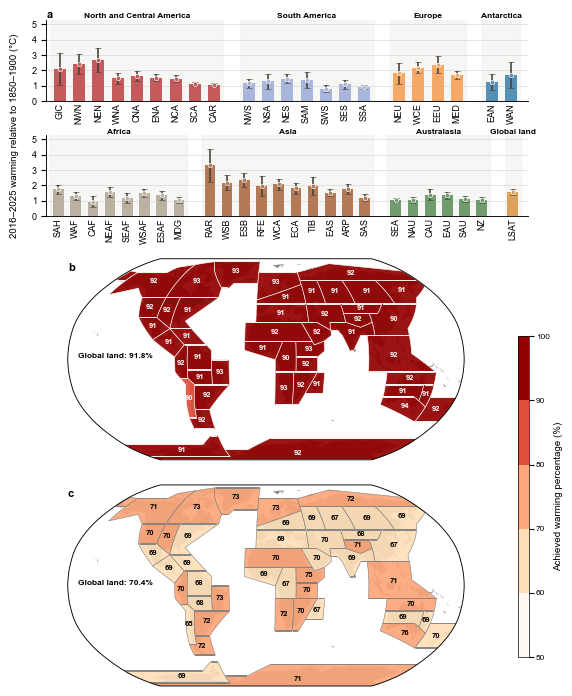

In [39]:
# Final dimensions: 180 × 185 mm, the maximum height for a two-column figure with a caption over 150 words.
EXPORT_TARGET_WIDTH_MM = 180
FIGURE_WIDTH_MM = EXPORT_TARGET_WIDTH_MM
FIGURE_HEIGHT_MM = 185
fig = plt.figure(figsize=(FIGURE_WIDTH_MM / 25.4, FIGURE_HEIGHT_MM / 25.4), constrained_layout=False)
gs = fig.add_gridspec(4, 1, height_ratios=[0.72, 0.72, 1.78, 1.78], hspace=0.24)
ax_a1 = fig.add_subplot(gs[0, 0])
ax_a2 = fig.add_subplot(gs[1, 0], sharey=ax_a1)
ax_b = fig.add_subplot(gs[2, 0], projection=ccrs.Robinson())
ax_c = fig.add_subplot(gs[3, 0], projection=ccrs.Robinson())
ax_b.set_anchor((0.25, 0.5))
ax_c.set_anchor((0.25, 0.5))

plot_regional_dot_whisker(ax_a1, warming, TOP, panel_label='a', show_ylabel=False)
plot_regional_dot_whisker(ax_a2, warming, BOTTOM, panel_label=None, show_ylabel=False)
fig.text(0.115, 0.805, '2016–2025 warming relative to 1850–1900 (°C)',
         rotation=90, va='center', ha='center', fontsize=7.0)

cmap = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=0.30)
norm = mcolors.BoundaryNorm(np.arange(50, 110, 10), ncolors=256, extend='neither')
plot_budget_map(ax_b, map_15, global_15, 'b', ' ', cmap, norm)
plot_budget_map(ax_c, map_20, global_20, 'c', ' ', cmap, norm)

cbar_ax = fig.add_axes([0.825, 0.090, 0.016, 0.440])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', ticks=np.arange(50, 110, 10))
cb.set_label('Achieved warming percentage (%)', labelpad=3.0, fontsize=7.0)
cb.ax.tick_params(labelsize=6.0, pad=1.5)
cb.outline.set_linewidth(0.5)

fig.subplots_adjust(left=0.16, right=0.84, top=0.965, bottom=0.050)
b_position = ax_b.get_position()
ax_b.set_position([b_position.x0, b_position.y0 - 0.012, b_position.width, b_position.height])
pdf_path = OUTPUT / 'Fig_1.pdf'
fig.savefig(pdf_path, format='pdf', metadata={'Title': 'Figure 1'}, bbox_inches='tight')
print(f'Saved {pdf_path}')
plt.show()
